## Import Libraries

In [ ]:
import pandas as pd
import numpy as np
import shap
import ast

from collections import defaultdict, deque
from xgboost import XGBClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, log_loss, roc_auc_score, f1_score, confusion_matrix, ConfusionMatrixDisplay

c:\Users\ACER\miniconda3\envs\mworld\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Feature Engineering
Create Relational features from absolute feature to prevent redundancy between features and make easier model to analize data pattern.

In [103]:
df_matches = pd.read_csv(r"E:\End-to-End-MLOps-MWorld-Champions\data\interim\matches.csv")
df_matches.head(10)

,match_keys,date,tier_name,tournament_name,stage_name,bracket_name,home_team,away_team,home_score,away_score,winner,score,match_id
0,2025-02-28 16:00:00+07:00_MPL Philippines Seas...,2025-02-28 16:00:00+07:00,A-Tier_Tournaments,MPL Philippines Season 15,Regular Season,Group Stage,twisted minds ph,aurora gaming ph,0,2,aurora gaming ph,0-2,1
1,2025-02-28 18:30:00+07:00_MPL Philippines Seas...,2025-02-28 18:30:00+07:00,A-Tier_Tournaments,MPL Philippines Season 15,Regular Season,Group Stage,onic philippines,tnc pro team,2,0,onic philippines,2-0,2
2,2025-03-01 13:30:00+07:00_MPL Philippines Seas...,2025-03-01 13:30:00+07:00,A-Tier_Tournaments,MPL Philippines Season 15,Regular Season,Group Stage,team falcons ph,team liquid ph,0,2,team liquid ph,0-2,3
3,2025-03-01 16:00:00+07:00_MPL Philippines Seas...,2025-03-01 16:00:00+07:00,A-Tier_Tournaments,MPL Philippines Season 15,Regular Season,Group Stage,tnc pro team,ap.bren,2,0,tnc pro team,2-0,4
4,2025-03-01 18:30:00+07:00_MPL Philippines Seas...,2025-03-01 18:30:00+07:00,A-Tier_Tournaments,MPL Philippines Season 15,Regular Season,Group Stage,aurora gaming ph,onic philippines,2,1,aurora gaming ph,2-1,5
5,2025-03-02 16:00:00+07:00_MPL Philippines Seas...,2025-03-02 16:00:00+07:00,A-Tier_Tournaments,MPL Philippines Season 15,Regular Season,Group Stage,omega esports,team falcons ph,0,2,team falcons ph,0-2,6
6,2025-03-02 18:30:00+07:00_MPL Philippines Seas...,2025-03-02 18:30:00+07:00,A-Tier_Tournaments,MPL Philippines Season 15,Regular Season,Group Stage,team liquid ph,twisted minds ph,2,0,team liquid ph,2-0,7
7,2025-03-07 15:15:00+07:00_MPL Indonesia Season...,2025-03-07 15:15:00+07:00,A-Tier_Tournaments,MPL Indonesia Season 15,Regular Season,Group Stage,natus vincere,rrq hoshi,0,2,rrq hoshi,0-2,8
8,2025-03-07 16:00:00+07:00_MPL Philippines Seas...,2025-03-07 16:00:00+07:00,A-Tier_Tournaments,MPL Philippines Season 15,Regular Season,Group Stage,team falcons ph,onic philippines,2,1,team falcons ph,2-1,9
9,2025-03-07 18:15:00+07:00_MPL Indonesia Season...,2025-03-07 18:15:00+07:00,A-Tier_Tournaments,MPL Indonesia Season 15,Regular Season,Group Stage,evos,team liquid id,2,1,evos,2-1,10


In [105]:
df_games = pd.read_csv(r"E:\End-to-End-MLOps-MWorld-Champions\data\interim\games.csv")
df_games.head(10)

,date,match_keys,game_keys,tier_name,tournament_name,stage_name,bracket_name,game_num,map_name,duration,...,away_gold_5mnt,home_gold_10mnt,away_gold_10mnt,home_gold_15mnt,away_gold_15mnt,home_gold_20mnt,away_gold_20mnt,game_id,home_score,away_score
0,2025-02-28 18:30:00+07:00,2025-02-28 18:30:00+07:00_MPL Philippines Seas...,2025-02-28 18:30:00+07:00_MPL Philippines Seas...,A-Tier_Tournaments,MPL Philippines Season 15,Regular Season,Group Stage,1,default,17:52,...,-1800.0,4000.0,-4000.0,4800.0,-4800.0,NaN,NaN,1,1,0
1,2025-02-28 18:30:00+07:00,2025-02-28 18:30:00+07:00_MPL Philippines Seas...,2025-02-28 18:30:00+07:00_MPL Philippines Seas...,A-Tier_Tournaments,MPL Philippines Season 15,Regular Season,Group Stage,2,default,21:55,...,67.0,-2700.0,2700.0,-6400.0,6400.0,-6000.0,6000.0,2,1,0
2,2025-02-28 16:00:00+07:00,2025-02-28 16:00:00+07:00_MPL Philippines Seas...,2025-02-28 16:00:00+07:00_MPL Philippines Seas...,A-Tier_Tournaments,MPL Philippines Season 15,Regular Season,Group Stage,1,default,18:52,...,1500.0,-3500.0,3500.0,-8000.0,8000.0,NaN,NaN,3,0,1
3,2025-02-28 16:00:00+07:00,2025-02-28 16:00:00+07:00_MPL Philippines Seas...,2025-02-28 16:00:00+07:00_MPL Philippines Seas...,A-Tier_Tournaments,MPL Philippines Season 15,Regular Season,Group Stage,2,default,13:52,...,1400.0,-7800.0,7800.0,NaN,NaN,NaN,NaN,4,0,1
4,2025-03-01 18:30:00+07:00,2025-03-01 18:30:00+07:00_MPL Philippines Seas...,2025-03-01 18:30:00+07:00_MPL Philippines Seas...,A-Tier_Tournaments,MPL Philippines Season 15,Regular Season,Group Stage,1,default,19:48,...,-1600.0,6900.0,-6900.0,5400.0,-5400.0,NaN,NaN,5,1,0
5,2025-03-01 18:30:00+07:00,2025-03-01 18:30:00+07:00_MPL Philippines Seas...,2025-03-01 18:30:00+07:00_MPL Philippines Seas...,A-Tier_Tournaments,MPL Philippines Season 15,Regular Season,Group Stage,2,default,12:41,...,-540.0,-1000.0,1000.0,NaN,NaN,NaN,NaN,6,0,1
6,2025-03-01 18:30:00+07:00,2025-03-01 18:30:00+07:00_MPL Philippines Seas...,2025-03-01 18:30:00+07:00_MPL Philippines Seas...,A-Tier_Tournaments,MPL Philippines Season 15,Regular Season,Group Stage,3,default,16:02,...,-153.0,3500.0,-3500.0,2600.0,-2600.0,NaN,NaN,7,1,0
7,2025-03-01 13:30:00+07:00,2025-03-01 13:30:00+07:00_MPL Philippines Seas...,2025-03-01 13:30:00+07:00_MPL Philippines Seas...,A-Tier_Tournaments,MPL Philippines Season 15,Regular Season,Group Stage,1,default,18:34,...,503.0,401.0,-401.0,-3500.0,3500.0,NaN,NaN,8,0,1
8,2025-03-01 13:30:00+07:00,2025-03-01 13:30:00+07:00_MPL Philippines Seas...,2025-03-01 13:30:00+07:00_MPL Philippines Seas...,A-Tier_Tournaments,MPL Philippines Season 15,Regular Season,Group Stage,2,default,12:31,...,1300.0,-8700.0,8700.0,NaN,NaN,NaN,NaN,9,0,1
9,2025-03-01 16:00:00+07:00,2025-03-01 16:00:00+07:00_MPL Philippines Seas...,2025-03-01 16:00:00+07:00_MPL Philippines Seas...,A-Tier_Tournaments,MPL Philippines Season 15,Regular Season,Group Stage,1,default,13:12,...,-2200.0,8200.0,-8200.0,NaN,NaN,NaN,NaN,10,1,0


Change a list contained feature into wide format

In [106]:
def item_explode(columns):
    team_picks = []
    for i in columns:
        stat = ast.literal_eval(i)
        team_picks.append(stat)
    return team_picks

for col in ["home_picks", "away_picks", "home_bans", "away_bans"]:
    df_games[col] = item_explode(df_games[col])

# df_games["home_picks"] = item_explode(df_games["home_picks"])
# df_games[["home_picks_1", "home_picks_2", "home_picks_3", "home_picks_4", "home_picks_5"]] = pd.DataFrame(df_games["home_picks"].tolist(), index=df_games.index)
# df_games["away_picks"] = item_explode(df_games["away_picks"])
# df_games[["away_picks_1", "away_picks_2", "away_picks_3", "away_picks_4", "away_picks_5"]] = pd.DataFrame(df_games["away_picks"].tolist(), index=df_games.index)
# df_games["home_bans"] = item_explode(df_games["home_bans"])
# df_games[["home_bans_1", "home_bans_2", "home_bans_3", "home_bans_4", "home_bans_5"]] = pd.DataFrame(df_games["home_bans"].tolist(), index=df_games.index)
# df_games["away_bans"] = item_explode(df_games["away_bans"])
# df_games[["away_bans_1", "away_bans_2", "away_bans_3", "away_bans_4", "away_bans_5"]] = pd.DataFrame(df_games["away_bans"].tolist(), index=df_games.index)

In [107]:
def kda_score(kill, assist, death):
    if np.nan in death or 0.0 in death:
        kda = kill + assist
        return kda
    
    kda = (kill + assist) / death
    return kda

def scale_score(feature1, feature2):
    if np.nan in feature1 or np.nan in feature2:
        return np.nan
    
    return feature1 / feature2

def diff_score(feature1, feature2):
    return feature1 - feature2
    
def time_converts(time_str):
    if pd.isna(time_str):
        return np.nan
    m, s = map(int, time_str.split(":"))
    duration = m + (s / 60)
    return duration

Create relational features such gold_eff, kda_diff, objective_diff, early_gold_diff, mid_gold_diff, late_gold_diff and comeback flag.

In [108]:
df_games["duration"] = [time_converts(i) for i in df_games["duration"]]
df_games["home_score"] = np.where(df_games["home_status"] == "win", 1, 0)
df_games["away_score"] = np.where(df_games["away_status"] == "win", 1, 0)
df_games["gold_total_diff"] = diff_score(df_games["home_gold_total"], df_games["away_gold_total"])
df_games["gold_eff"] = scale_score(df_games["gold_total_diff"], df_games["duration"])
df_games["objective_diff"] = diff_score(
    df_games["home_turtles"] + df_games["home_lords"] + df_games["home_towers"],
    df_games["away_turtles"] + df_games["away_lords"] + df_games["away_towers"]
)
df_games["kda_diff"] = diff_score(
    kda_score(df_games["home_kills"], df_games["home_assists"], df_games["home_deaths"]),
    kda_score(df_games["away_kills"], df_games["away_assists"], df_games["away_deaths"])
)
df_games["early_gold_diff"] = diff_score(df_games["home_gold_10mnt"], df_games["home_gold_5mnt"])
df_games["mid_gold_diff"] = diff_score(df_games["home_gold_15mnt"], df_games["home_gold_10mnt"])
df_games["late_gold_diff"] = diff_score(df_games["home_gold_20mnt"], df_games["home_gold_15mnt"])
df_games["home_is_comeback"] = (((df_games["early_gold_diff"] < 0) | (df_games["mid_gold_diff"] < 0) | (df_games["early_gold_diff"] < 0)) & (df_games["home_score"] == 1)).astype(int)
df_games["home_behind_any_phase"] = ((df_games["early_gold_diff"] < 0) | (df_games["mid_gold_diff"] < 0) | (df_games["late_gold_diff"] < 0)).astype(int)
df_games["away_is_comeback"] = (((-(df_games["early_gold_diff"]) < 0) | (-(df_games["mid_gold_diff"]) < 0) | (-(df_games["early_gold_diff"]) < 0)) & (df_games["away_score"] == 1)).astype(int)
df_games["away_behind_any_phase"] = ((-(df_games["early_gold_diff"]) < 0) | (-(df_games["mid_gold_diff"]) < 0) | (-(df_games["late_gold_diff"]) < 0)).astype(int)
df_games = df_games.drop(columns=df_games.columns[20:44])
df_games = df_games.drop(columns=["home_status", "away_status"])

In [109]:
df_games.head(10)

,date,match_keys,game_keys,tier_name,tournament_name,stage_name,bracket_name,game_num,map_name,duration,...,gold_eff,objective_diff,kda_diff,early_gold_diff,mid_gold_diff,late_gold_diff,home_is_comeback,home_behind_any_phase,away_is_comeback,away_behind_any_phase
0,2025-02-28 18:30:00+07:00,2025-02-28 18:30:00+07:00_MPL Philippines Seas...,2025-02-28 18:30:00+07:00_MPL Philippines Seas...,A-Tier_Tournaments,MPL Philippines Season 15,Regular Season,Group Stage,1,default,17.866667,...,380.597015,7.0,26.0,2200.0,800.0,NaN,0,0,0,1
1,2025-02-28 18:30:00+07:00,2025-02-28 18:30:00+07:00_MPL Philippines Seas...,2025-02-28 18:30:00+07:00_MPL Philippines Seas...,A-Tier_Tournaments,MPL Philippines Season 15,Regular Season,Group Stage,2,default,21.916667,...,136.882129,-7.0,-19.0,-2633.0,-3700.0,400.0,1,1,0,1
2,2025-02-28 16:00:00+07:00,2025-02-28 16:00:00+07:00_MPL Philippines Seas...,2025-02-28 16:00:00+07:00_MPL Philippines Seas...,A-Tier_Tournaments,MPL Philippines Season 15,Regular Season,Group Stage,1,default,18.866667,...,-482.332155,-6.0,-32.0,-2000.0,-4500.0,NaN,0,1,0,0
3,2025-02-28 16:00:00+07:00,2025-02-28 16:00:00+07:00_MPL Philippines Seas...,2025-02-28 16:00:00+07:00_MPL Philippines Seas...,A-Tier_Tournaments,MPL Philippines Season 15,Regular Season,Group Stage,2,default,13.866667,...,-937.500000,-14.0,-23.0,-6400.0,NaN,NaN,0,1,0,0
4,2025-03-01 18:30:00+07:00,2025-03-01 18:30:00+07:00_MPL Philippines Seas...,2025-03-01 18:30:00+07:00_MPL Philippines Seas...,A-Tier_Tournaments,MPL Philippines Season 15,Regular Season,Group Stage,1,default,19.800000,...,262.626263,14.0,8.0,5300.0,-1500.0,NaN,1,1,0,1
5,2025-03-01 18:30:00+07:00,2025-03-01 18:30:00+07:00_MPL Philippines Seas...,2025-03-01 18:30:00+07:00_MPL Philippines Seas...,A-Tier_Tournaments,MPL Philippines Season 15,Regular Season,Group Stage,2,default,12.683333,...,-433.639947,-7.0,-29.0,-1540.0,NaN,NaN,0,1,0,0
6,2025-03-01 18:30:00+07:00,2025-03-01 18:30:00+07:00_MPL Philippines Seas...,2025-03-01 18:30:00+07:00_MPL Philippines Seas...,A-Tier_Tournaments,MPL Philippines Season 15,Regular Season,Group Stage,3,default,16.033333,...,187.110187,3.0,41.0,3347.0,-900.0,NaN,1,1,0,1
7,2025-03-01 13:30:00+07:00,2025-03-01 13:30:00+07:00_MPL Philippines Seas...,2025-03-01 13:30:00+07:00_MPL Philippines Seas...,A-Tier_Tournaments,MPL Philippines Season 15,Regular Season,Group Stage,1,default,18.566667,...,-355.475763,-7.0,-28.0,904.0,-3901.0,NaN,0,1,1,1
8,2025-03-01 13:30:00+07:00,2025-03-01 13:30:00+07:00_MPL Philippines Seas...,2025-03-01 13:30:00+07:00_MPL Philippines Seas...,A-Tier_Tournaments,MPL Philippines Season 15,Regular Season,Group Stage,2,default,12.516667,...,-990.679095,-12.0,-26.0,-7400.0,NaN,NaN,0,1,0,0
9,2025-03-01 16:00:00+07:00,2025-03-01 16:00:00+07:00_MPL Philippines Seas...,2025-03-01 16:00:00+07:00_MPL Philippines Seas...,A-Tier_Tournaments,MPL Philippines Season 15,Regular Season,Group Stage,1,default,13.200000,...,803.030303,9.0,43.0,6000.0,NaN,NaN,0,0,0,1


Aggregation games based dataset into match based dataset

In [110]:
match_stat_avg = df_games.groupby(["match_keys"]).agg(
    duration=("duration", "mean"),
    home_team=("home_team", "first"),
    away_team=("away_team", "first"),
    gold_total_diff=("gold_total_diff", "mean"),
    gold_eff=("gold_eff", "mean"),
    objective_diff=("objective_diff", "mean"),
    kda_diff=("kda_diff", "mean"),
    early_gold_diff=("early_gold_diff", "mean"),
    mid_gold_diff=("mid_gold_diff", "mean"),
    late_gold_diff=("late_gold_diff", "mean"),
    home_is_comeback=("home_is_comeback", "sum"),
    home_behind_any_phase=("home_behind_any_phase", "sum"),
    away_is_comeback=("away_is_comeback", "sum"),
    away_behind_any_phase=("away_behind_any_phase", "sum")
).reset_index()
match_stat_avg["home_comeback_rate"] = (match_stat_avg["home_is_comeback"] / match_stat_avg["home_behind_any_phase"]).fillna(0).round(2)
match_stat_avg["away_comeback_rate"] = (match_stat_avg["away_is_comeback"] / match_stat_avg["away_behind_any_phase"]).fillna(0).round(2)
match_stat_avg["comeback_rate_diff"] = diff_score(match_stat_avg["home_comeback_rate"], match_stat_avg["away_comeback_rate"])
match_stat_avg[["gold_total_diff", "gold_eff", "objective_diff", "kda_diff", "early_gold_diff", "mid_gold_diff", "late_gold_diff"]] = match_stat_avg[["gold_total_diff", "gold_eff", "objective_diff", "kda_diff", "early_gold_diff", "mid_gold_diff", "late_gold_diff"]].round()
match_stat_avg["duration"] = match_stat_avg["duration"].round(2)
match_stat_avg

,match_keys,duration,home_team,away_team,gold_total_diff,gold_eff,objective_diff,kda_diff,early_gold_diff,mid_gold_diff,late_gold_diff,home_is_comeback,home_behind_any_phase,away_is_comeback,away_behind_any_phase,home_comeback_rate,away_comeback_rate,comeback_rate_diff
0,2025-02-28 16:00:00+07:00_MPL Philippines Seas...,16.37,twisted minds ph,aurora gaming ph,-11050.0,-710.0,-10.0,-28.0,-4200.0,-4500.0,NaN,0,2,0,0,0.00,0.00,0.00
1,2025-02-28 18:30:00+07:00_MPL Philippines Seas...,19.89,onic philippines,tnc pro team,4900.0,259.0,0.0,4.0,-216.0,-1450.0,400.0,1,1,0,2,1.00,0.00,1.00
2,2025-03-01 13:30:00+07:00_MPL Philippines Seas...,15.54,team falcons ph,team liquid ph,-9500.0,-673.0,-10.0,-27.0,-3248.0,-3901.0,NaN,0,2,1,1,0.00,1.00,-1.00
3,2025-03-01 16:00:00+07:00_MPL Philippines Seas...,12.18,tnc pro team,ap.bren,8550.0,693.0,10.0,40.0,5750.0,NaN,NaN,0,0,0,2,0.00,0.00,0.00
4,2025-03-01 18:30:00+07:00_MPL Philippines Seas...,16.17,aurora gaming ph,onic philippines,900.0,5.0,3.0,7.0,2369.0,-1200.0,NaN,2,3,0,2,0.67,0.00,0.67
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1280,2025-12-21 20:45:00+07:00_Games of the Future ...,18.97,onic,team falcons,6400.0,388.0,6.0,22.0,1767.0,4233.0,600.0,0,0,1,3,0.00,0.33,-0.33
1281,2025-12-22 18:00:00+07:00_Games of the Future ...,17.41,dianfengyaoguai,aurora gaming,-6567.0,-453.0,-7.0,-47.0,-3367.0,-4367.0,600.0,1,3,0,1,0.33,0.00,0.33
1282,2025-12-22 20:00:00+07:00_Games of the Future ...,16.39,aurora gaming ph,onic,-10200.0,-667.0,-9.0,-36.0,-1900.0,-5600.0,NaN,0,2,1,1,0.00,1.00,-1.00
1283,2025-12-23 18:00:00+07:00_Games of the Future ...,17.90,dianfengyaoguai,aurora gaming ph,-11750.0,-659.0,-8.0,-64.0,-1900.0,-5800.0,-700.0,0,2,0,0,0.00,0.00,0.00


In [111]:
df_games["bracket_name"].unique()

array(['Group Stage', 'Quarterfinals', 'Semifinals', 'Grand Final',
       'Upper Bracket Quaterfinals', 'Upper Bracket Semifinals',
       'Upper Bracket Final', 'Lower Bracket Final',
       'Lower Bracket Semifinal', 'Upper Bracket Quarterfinals',
       'Lower Bracket Quarterfinals', 'Lower Bracket Round 1', 'Final',
       'Finals', 'Upper Bracket Seminfinals', 'Lower Bracket Semifinals',
       'Upper Bracket Quartefinals', 'Third Place Match',
       'Upper Bracket Round 1', 'Play-In', 'Lower Bracket Quaterfinals',
       'Play-Ins', 'Third Place'], dtype=object)

In [ ]:
# # Update soon
# # Weight feature for pressure score
# tier_map = {
#     "S-Tier_Tournaments": 1.6,
#     "A-Tier_Tournaments": 1.4,
#     "B-Tier_Tournaments": 1.2,
#     "Qualifier_Tournaments": 1.0,
# }
# stage_map= {
#     "Playoffs": 1.6,
#     "Regular Season": 1.4,
#     "Group Stage": 1.4,
#     "Stage 2": 1.4,
#     "Play-In": 1.2,
#     "Play-Ins": 1.2,
#     "wildcard Playoffs": 1.2,
#     "Wildcard Group Stage": 1.0,
#     "Last Chance Qualifier": 1.0,
#     "Last Chance": 1.0,
#     "Challenger": 1.0,
# }
# bracket_map = {
#     "Grand Final": ,
#     "Third Place Match",
#     "Third Place",
#     "Final",
#     "Finals",
#     "Upper Bracket Final",
#     "Lower Bracket Final",
#     "Group Stage",
#     "Quarterfinals",
#     "Semifinals",
#     "Upper Bracket Semifinals",
#     "Lower Bracket Semifinal",
#     "Upper Bracket Seminfinals",
#     "Lower Bracket Semifinals",
#     "Upper Bracket Quarterfinals",
#     "Upper Bracket Quaterfinals",
#     "Upper Bracket Quartefinals",
#     "Lower Bracket Quarterfinals",
#     "Lower Bracket Quaterfinals",
#     "Upper Bracket Round 1": 0.6,
#     "Lower Bracket Round 1": 0.6,
#     "Play-In": 0.6,
#     "Play-Ins": 0.6,
# }

Merging statitistic score dataset and match statistic from aggregation into a single dataset.

In [62]:
matches_cleaned = df_matches.merge(match_stat_avg, how="left", on="match_keys")
matches_cleaned = matches_cleaned.drop(columns=[
    "home_is_comeback", "away_is_comeback", "home_behind_any_phase", "away_behind_any_phase", "home_comeback_rate", "away_comeback_rate", "home_team_y", "away_team_y"
    ]).rename(columns={
    "home_team_x": "home_team", "away_team_x": "away_team"
})
matches_cleaned

,match_id,match_keys,date,tournament_name,stage_name,bracket_name,home_team,away_team,home_score,away_score,...,winner,duration,gold_total_diff,gold_eff,objective_diff,kda_diff,early_gold_diff,mid_gold_diff,late_gold_diff,comeback_rate_diff
0,1,2025-02-28 18:30:00+07:00_MPL Philippines Seas...,2025-02-28 18:30:00+07:00,MPL Philippines Season 15,Regular Season,Group Stage,onic philippines,tnc pro team,2,0,...,onic philippines,19.89,4900.0,259.0,0.0,4.0,-216.0,-1450.0,400.0,1.00
1,2,2025-02-28 16:00:00+07:00_MPL Philippines Seas...,2025-02-28 16:00:00+07:00,MPL Philippines Season 15,Regular Season,Group Stage,twisted minds ph,aurora gaming ph,0,2,...,aurora gaming ph,16.37,-11050.0,-710.0,-10.0,-28.0,-4200.0,-4500.0,NaN,0.00
2,3,2025-03-01 18:30:00+07:00_MPL Philippines Seas...,2025-03-01 18:30:00+07:00,MPL Philippines Season 15,Regular Season,Group Stage,aurora gaming ph,onic philippines,2,1,...,aurora gaming ph,16.17,900.0,5.0,3.0,7.0,2369.0,-1200.0,NaN,0.67
3,4,2025-03-01 13:30:00+07:00_MPL Philippines Seas...,2025-03-01 13:30:00+07:00,MPL Philippines Season 15,Regular Season,Group Stage,team falcons ph,team liquid ph,0,2,...,team liquid ph,15.54,-9500.0,-673.0,-10.0,-27.0,-3248.0,-3901.0,NaN,-1.00
4,5,2025-03-01 16:00:00+07:00_MPL Philippines Seas...,2025-03-01 16:00:00+07:00,MPL Philippines Season 15,Regular Season,Group Stage,tnc pro team,ap.bren,2,0,...,tnc pro team,12.18,8550.0,693.0,10.0,40.0,5750.0,NaN,NaN,0.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1278,1279,2025-12-21 15:00:00+07:00_Games of the Future ...,2025-12-21 15:00:00+07:00,Games of the Future 2025,Playoffs,Semi-Final,rrq hoshi,dianfengyaoguai,1,2,...,dianfengyaoguai,15.56,-300.0,-11.0,-1.0,1.0,733.0,500.0,-3600.0,-0.50
1279,1280,2025-12-22 20:00:00+07:00_Games of the Future ...,2025-12-22 20:00:00+07:00,Games of the Future 2025,Playoffs,Final,aurora gaming ph,onic,0,2,...,onic,16.39,-10200.0,-667.0,-9.0,-36.0,-1900.0,-5600.0,NaN,-1.00
1280,1281,2025-12-22 18:00:00+07:00_Games of the Future ...,2025-12-22 18:00:00+07:00,Games of the Future 2025,Playoffs,Final,dianfengyaoguai,aurora gaming,1,2,...,aurora gaming,17.41,-6567.0,-453.0,-7.0,-47.0,-3367.0,-4367.0,600.0,0.33
1281,1282,2025-12-23 21:00:00+07:00_Games of the Future ...,2025-12-23 21:00:00+07:00,Games of the Future 2025,Playoffs,Grand Final,aurora gaming,onic,0,3,...,onic,15.84,-12400.0,-802.0,-12.0,-43.0,-5700.0,-2500.0,NaN,0.00


Load team dataset

In [225]:
df_teams = pd.read_csv(r"E:\End-to-End-MLOps-MWorld-Champions\data\interim\teams.csv")
df_teams

,team_name,team_region,team_id
0,rrq hoshi,Indonesia,1
1,onic,Indonesia,2
2,s8ul esports,India,3
3,team liquid ph,Philippines,4
4,selangor red giants,Malaysia,5
...,...,...,...
159,ra'ad,MENA,160
160,violance,Turkey,161
161,papara supermassive,Turkey,162
162,bad idea right,Turkey,163


### Creating elo features and historical statistic data dataset for prediction 
Define 1500 as default elo values for each team. then calculate elo use elo formula. You can explore elo formula on wikipedia.

In [226]:
region = dict(zip(df_teams["team_name"], df_teams["team_region"]))
region

{'rrq hoshi': 'Indonesia',
 'onic': 'Indonesia',
 's8ul esports': 'India',
 'team liquid ph': 'Philippines',
 'selangor red giants': 'Malaysia',
 'influence rage': 'Latin America',
 'homebois': 'Malaysia',
 'legion esports': 'Vietnam',
 'onic philippines': 'Indonesia',
 'team spirit': 'CIS',
 'cfu gaming': 'Cambodia',
 'virtus.pro': 'CIS',
 'ultra legends': 'MENA',
 'zeta division': 'Japan',
 'mythic seal': 'Myanmar',
 'team falcons': 'MENA',
 'area 77': 'North America',
 'team flash': 'Malaysia',
 'dianfengyaoguai': 'China',
 'aurora gaming': 'Turkey',
 'corinthians': 'Latin America',
 'rare atom': 'China',
 'the mongolz': 'Mongolia',
 'niightmare esports': 'Laos',
 'llg open sesame': 'Japan',
 'inari perfection': 'Japan',
 'u2 esports': 'Japan',
 'yg': 'China',
 'xty': 'China',
 'tidal legends gaming': 'China',
 'ybingame': 'China',
 'the young gaming': 'China',
 'keepbest gaming': 'China',
 'ying jiang nan': 'China',
 'gdy': 'China',
 'guangzhou gaming': 'China',
 'invictus gaming':

In [227]:
elo = {team: 1500 for team in df_teams["team_name"]}
region_winrate = {r: 0 for r in df_teams["team_region"].unique()}
region_momentum = {r: 0 for r in df_teams["team_region"].unique()}

In [228]:
# Calculate Draft intelligence (on progress)
hero_stat = defaultdict(lambda:{
    "win": 0,
    "total": 0
})

# Smooting constant
gamma = 0.05

def get_hero_winrate(team, hero):
    key = (team, hero)
    stats = hero_stat[key]

    if stats["total"] == 0:
        return 0.5
    
    return stats["win"] * gamma * 0.5 / stats["total"]


In [229]:
def expected_score(t1, t2):
    return 1 / (1 + 10**((t1-t2)/400))

def diff_score(feature1, feature2):
    return feature1 - feature2

def mean_feature(result):
    return np.nanmean(result) if len(result) > 0 else 0.5

def winrate_last_n(result):
    return np.nanmean(result) if len(result) > 0 else 0.5

def momentum(result):
    if len(result) < 2 :
        return 0

    result = list(result)
    mid = len(result) // 2
    return np.nanmean(result[mid:]) - np.nanmean(result[:mid]) if len(result[:mid]) > 0 or len(result[mid:]) > 0 else 0


team_stat = defaultdict(lambda: {
    "result": deque(maxlen=5),
    "scaling_diff": deque(maxlen=5),
    "objective_diff": deque(maxlen=5),
    "kda_diff": deque(maxlen=5),
    "gold_total_diff": deque(maxlen=5),
    "early_gold_diff": deque(maxlen=5),
    "mid_gold_diff": deque(maxlen=5),
    "late_gold_diff": deque(maxlen=5),
    "momentum_diff": deque(maxlen=5),
    "comeback_rate_diff": deque(maxlen=5)
})

history = []

k = 32
alpha = 2
beta = 0.01

for i, row in matches_cleaned.iterrows():
    keys = row["match_keys"]
    t1, t2 = row["home_team"], row["away_team"]
    duration = row["duration"]
    gold_eff = row["gold_eff"]
    gold_total_diff = row["gold_total_diff"]
    early_gold_diff = row["early_gold_diff"]
    mid_gold_diff = row["mid_gold_diff"]
    late_gold_diff = row["late_gold_diff"]
    kda_diff = row["kda_diff"]
    objective_diff = row["objective_diff"]
    comeback_rate_diff = row["comeback_rate_diff"]
    sc1, sc2 = row["home_score"], row["away_score"]
    winner = row["winner"]
    
    ts1, ts2 = team_stat[t1], team_stat[t2]
    r1, r2 = elo[t1], elo[t2]
    
    # Elo Calculation
    elo_diff = diff_score(r1, r2)

    exp1 = expected_score(r1, r2)
    exp2 = expected_score(r2, r1)

    s1 = 1 if winner == t1 else 0.5 if winner == "tie" else 0
    s2 = 1 if winner == t2 else 0.5 if winner == "tie" else 0

    elo[t1] += k * (s1 - exp1)
    elo[t2] += k * (s2 - exp2)

    # KDA diff
    kda_diff_ = diff_score(mean_feature(ts1["kda_diff"]), mean_feature(ts2["kda_diff"]))
    kda1 = kda_diff
    kda2 = -kda_diff

    # Objective diff
    obj_diff = diff_score(mean_feature(ts1["objective_diff"]), mean_feature(ts2["objective_diff"]))
    obj1 = objective_diff
    obj2 = -objective_diff

    # Scaling diff
    scaling_diff_ = diff_score(mean_feature(ts1["scaling_diff"]), mean_feature(ts2["scaling_diff"]))
    scaling1 = gold_eff
    scaling2 = -gold_eff

    # Gold total diff
    g_diff = diff_score(mean_feature(ts1["gold_total_diff"]), mean_feature(ts2["gold_total_diff"]))
    g_diff1 = gold_total_diff
    g_diff2 = -gold_total_diff

    # Early gold diff
    early_diff = diff_score(mean_feature(ts1["early_gold_diff"]), mean_feature(ts2["early_gold_diff"]))
    early_diff1 = early_gold_diff
    early_diff2 = -early_gold_diff

    # Mid gold diff
    mid_diff = diff_score(mean_feature(ts1["mid_gold_diff"]), mean_feature(ts2["mid_gold_diff"]))
    mid_diff1 = mid_gold_diff
    mid_diff2 = -mid_gold_diff

    # Late gold diff
    late_diff = diff_score(mean_feature(ts1["late_gold_diff"]), mean_feature(ts2["late_gold_diff"]))
    late_diff1 = late_gold_diff
    late_diff2 = -late_gold_diff

    # Comeback rate diff
    comeback_rate_diff_ = diff_score(mean_feature(ts1["comeback_rate_diff"]), mean_feature(ts2["comeback_rate_diff"]))
    comeback_rate_diff1 = comeback_rate_diff
    comeback_rate_diff2 = -comeback_rate_diff

    # last 5 match winrate difference calculation
    hist_t1, hist_t2  = ts1["result"], ts2["result"]

    wr1 = winrate_last_n(hist_t1)
    wr2 = winrate_last_n(hist_t2)

    winrate_diff = diff_score(wr1, wr2)

    # last 5 match momentum difference calculation

    mom_t1 = momentum(hist_t1)
    mom_t2 = momentum(hist_t2)

    momentum_diff = diff_score(mom_t1, mom_t2)
    
    history.append({
        "match_keys": keys,
        "duration": duration,
        "label": 1 if winner == t1 else 0 if winner == t2 else 0.5,
        "home_team": t1,
        "away_team": t2,
        "elo_diff": elo_diff,
        "kda_diff": kda_diff_,
        "objective_diff": obj_diff,
        "gold_total_diff": g_diff,
        "early_gold_diff": early_diff,
        "mid_gold_diff": mid_diff,
        "late_gold_diff": late_diff,
        "winrate_diff": winrate_diff,
        "momentum_diff": momentum_diff,
        "scaling_diff": scaling_diff_,
        "comeback_rate_diff": comeback_rate_diff_
    })

    # Update team 1
    team_stat[t1]["kda_diff"].append(kda1)
    team_stat[t1]["gold_total_diff"].append(g_diff1)
    team_stat[t1]["objective_diff"].append(obj1)
    team_stat[t1]["scaling_diff"].append(scaling1)
    team_stat[t1]["early_gold_diff"].append(early_diff1)
    team_stat[t1]["mid_gold_diff"].append(mid_diff1)
    team_stat[t1]["late_gold_diff"].append(late_diff)
    team_stat[t1]["momentum_diff"].append(mom_t1)
    team_stat[t1]["comeback_rate_diff"].append(comeback_rate_diff1)
    team_stat[t1]["result"].append(s1)

    # Update team 2
    team_stat[t2]["kda_diff"].append(kda2)
    team_stat[t2]["gold_total_diff"].append(g_diff2)
    team_stat[t2]["objective_diff"].append(obj2)
    team_stat[t2]["scaling_diff"].append(scaling2)
    team_stat[t2]["early_gold_diff"].append(early_diff2)
    team_stat[t2]["mid_gold_diff"].append(mid_diff2)
    team_stat[t2]["late_gold_diff"].append(late_diff2)
    team_stat[t2]["momentum_diff"].append(mom_t2)
    team_stat[t2]["comeback_rate_diff"].append(comeback_rate_diff2)
    team_stat[t2]["result"].append(s2)

C:\Users\ACER\AppData\Local\Temp\ipykernel_15744\1114830865.py:8: RuntimeWarning: Mean of empty slice
  return np.nanmean(result) if len(result) > 0 else 0.5


In [230]:
elo = pd.DataFrame.from_dict(elo, orient='index', columns=["elo"]).reset_index(names="team_name")
df_teams = df_teams.merge(elo, on="team_name", how="left")
df_teams.sort_values(by="elo", ascending=False)

,team_name,team_region,team_id,elo
9,team spirit,CIS,10,2214.084716
8,onic philippines,Indonesia,9,2191.067004
0,rrq hoshi,Indonesia,1,2163.260789
3,team liquid ph,Philippines,4,2162.138854
4,selangor red giants,Malaysia,5,2106.960730
...,...,...,...,...
132,twisted minds ph,Philippines,133,1104.871660
128,ap.bren,Philippines,129,1097.976510
131,omega esports,Philippines,132,1091.364248
94,ombra esports,CIS,95,917.666792


create missing flag for missing values contained in feature

In [88]:
df_final = pd.DataFrame(history)
for col in ["gold_total_diff", "early_gold_diff", "mid_gold_diff", "late_gold_diff"]: # "early_gold_diff", "mid_gold_diff", "late_gold_diff"
    df_final[col] = pd.to_numeric(df_final[col], errors="coerce")
    df_final[col + "_missing"] = df_final[col].isna().astype(int)
    df_final[col] = df_final[col].fillna(df_final[col].median())
# df_final.to_csv(r"E:\End-to-End-MLOps-MWorld-Champions\data\processed\matches_stat.csv")
df_final

,match_keys,duration,label,home_team,away_team,elo_diff,kda_diff,objective_diff,gold_total_diff,early_gold_diff,mid_gold_diff,late_gold_diff,winrate_diff,momentum_diff,scaling_diff,comeback_rate_diff,gold_total_diff_missing,early_gold_diff_missing,mid_gold_diff_missing,late_gold_diff_missing
0,2025-02-28 18:30:00+07:00_MPL Philippines Seas...,19.89,1,onic philippines,tnc pro team,0.000000,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.000000,0.0,0.000,0,0,0,0
1,2025-02-28 16:00:00+07:00_MPL Philippines Seas...,16.37,0,twisted minds ph,aurora gaming ph,0.000000,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.000000,0.0,0.000,0,0,0,0
2,2025-03-01 18:30:00+07:00_MPL Philippines Seas...,16.17,1,aurora gaming ph,onic philippines,0.000000,24.0,10.0,6150.0,4416.0,5950.0,0.000000,0.0,0.000000,451.0,-1.000,0,0,0,1
3,2025-03-01 13:30:00+07:00_MPL Philippines Seas...,15.54,0,team falcons ph,team liquid ph,0.000000,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.000000,0.0,0.000,0,0,0,0
4,2025-03-01 16:00:00+07:00_MPL Philippines Seas...,12.18,1,tnc pro team,ap.bren,-16.000000,-4.0,0.0,-4900.0,216.0,1450.0,-400.000000,-0.5,0.000000,-259.0,-1.000,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1278,2025-12-21 15:00:00+07:00_Games of the Future ...,15.56,0,rrq hoshi,dianfengyaoguai,360.229665,23.6,0.4,2511.8,-436.6,2585.0,3831.757125,0.0,0.833333,172.6,-0.234,0,0,0,0
1279,2025-12-22 20:00:00+07:00_Games of the Future ...,16.39,0,aurora gaming ph,onic,21.946162,-5.4,0.4,-1729.6,120.6,-1832.5,-15710.835720,-0.2,0.500000,-106.0,-0.044,0,0,0,0
1280,2025-12-22 18:00:00+07:00_Games of the Future ...,17.41,0,dianfengyaoguai,aurora gaming,-233.589455,-36.8,-4.4,-6885.8,-2086.8,-3997.5,-4715.072452,-0.2,-0.333333,-458.2,0.134,0,0,0,0
1281,2025-12-23 21:00:00+07:00_Games of the Future ...,15.84,0,aurora gaming,onic,25.098508,10.2,1.0,116.8,1423.0,346.8,-13203.156114,0.0,0.000000,25.6,-0.494,0,0,0,0


Checking feature correlation

In [178]:
df_final["duration"] = df_final["duration"].fillna(np.mean(df_final["duration"]), axis=0)
df_final["kda_diff"] = df_final["kda_diff"].fillna(np.mean(df_final["kda_diff"]), axis=0)
df_final["objective_diff"] = df_final["objective_diff"].fillna(np.mean(df_final["objective_diff"]), axis=0)
df_final["scaling_diff"] = df_final["scaling_diff"].fillna(np.mean(df_final["scaling_diff"]), axis=0)
numerical_feature = df_final.select_dtypes(include=np.number)
numerical_feature.corr()

,duration,label,elo_diff,kda_diff,objective_diff,gold_total_diff,early_gold_diff,mid_gold_diff,late_gold_diff,winrate_diff,momentum_diff,scaling_diff,comeback_rate_diff,gold_total_diff_missing,early_gold_diff_missing,mid_gold_diff_missing,late_gold_diff_missing
duration,1.000000,-0.030920,-0.034984,-0.004475,-2.555383e-02,-0.015898,-0.029573,-0.049829,-0.007064,-0.018309,-0.016600,-1.880802e-02,-0.011947,7.910436e-03,1.681552e-03,-0.049816,-0.065958
label,-0.030920,1.000000,0.254367,0.309529,3.344890e-01,0.309983,0.329524,0.120501,-0.002246,0.310659,-0.003427,3.112687e-01,0.119997,1.958802e-03,-9.596884e-03,0.035379,0.009872
elo_diff,-0.034984,0.254367,1.000000,0.363103,3.947156e-01,0.354438,0.345759,0.165091,-0.011657,0.412113,-0.018381,3.471694e-01,0.186487,-5.932952e-03,-5.250332e-03,-0.018044,-0.044498
kda_diff,-0.004475,0.309529,0.363103,1.000000,8.703058e-01,0.829772,0.817353,0.329168,0.050628,0.803936,-0.001332,8.206634e-01,0.368870,8.805281e-03,4.329041e-03,0.022761,0.028769
objective_diff,-0.025554,0.334489,0.394716,0.870306,1.000000e+00,0.855162,0.875912,0.374401,0.014507,0.842382,-0.004770,8.491257e-01,0.342732,-2.677240e-18,2.525344e-18,0.041815,0.037131
gold_total_diff,-0.015898,0.309983,0.354438,0.829772,8.551619e-01,1.000000,0.789710,0.342640,0.085710,0.790755,0.008228,9.893764e-01,0.378881,-7.315580e-04,-6.540696e-04,0.038250,0.050741
early_gold_diff,-0.029573,0.329524,0.345759,0.817353,8.759116e-01,0.789710,1.000000,0.247150,0.018135,0.746420,-0.003350,8.006430e-01,0.199599,1.978174e-02,-9.255453e-04,0.029686,0.021324
mid_gold_diff,-0.049829,0.120501,0.165091,0.329168,3.744008e-01,0.342640,0.247150,1.000000,-0.027913,0.323310,-0.012329,3.119786e-01,0.071405,1.191175e-02,-1.837458e-03,-0.007893,-0.036720
late_gold_diff,-0.007064,-0.002246,-0.011657,0.050628,1.450698e-02,0.085710,0.018135,-0.027913,1.000000,0.037765,-0.005534,8.419870e-02,0.053394,-1.040243e-02,-7.539789e-03,0.002162,0.006189
winrate_diff,-0.018309,0.310659,0.412113,0.803936,8.423816e-01,0.790755,0.746420,0.323310,0.037765,1.000000,-0.029680,7.692331e-01,0.518089,-7.310441e-03,-7.271354e-03,0.006214,0.032154


## Feature Selection and Modeling
Experiment with all feature and model then evaluate for seeking importance feature using model coef and SHAP Analysis for final training. At the end, using selected feature to train model and make a prediction then do error analysis and segment analysis to know better about the model itself works.

Logistic
[[-0.07653731  0.29402603  0.0817481   0.23484514 -0.17349899  0.15020894
  -0.00213427 -0.10464328  0.15065208 -0.01061222  0.31805743 -0.04930701
   0.20760476 -0.23837315  0.12923973 -0.0342577 ]]


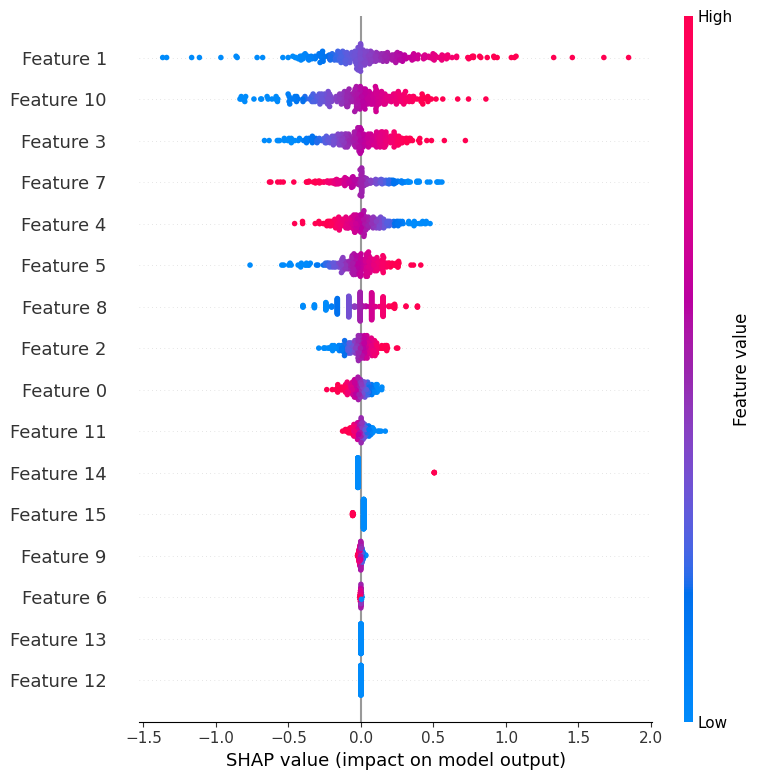

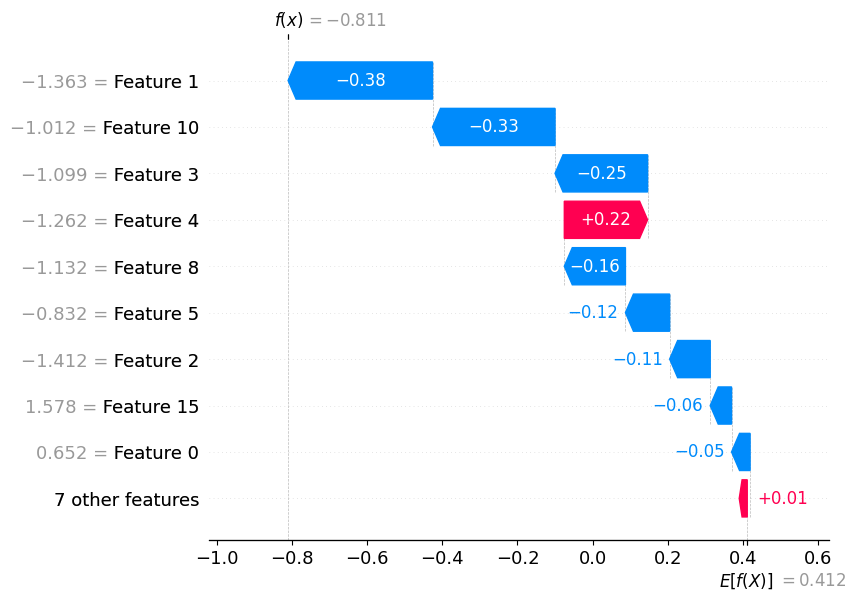

RF
                    feature  importance
0                  duration    0.140738
4           gold_total_diff    0.103032
1                  elo_diff    0.099470
10             scaling_diff    0.098050
3            objective_diff    0.089808
5           early_gold_diff    0.080667
2                  kda_diff    0.079875
11       comeback_rate_diff    0.070672
6             mid_gold_diff    0.070569
7            late_gold_diff    0.064721
8              winrate_diff    0.046821
9             momentum_diff    0.043362
15   late_gold_diff_missing    0.008813
14    mid_gold_diff_missing    0.003115
13  early_gold_diff_missing    0.000159
12  gold_total_diff_missing    0.000129
RF
not list
(257, 16, 2)


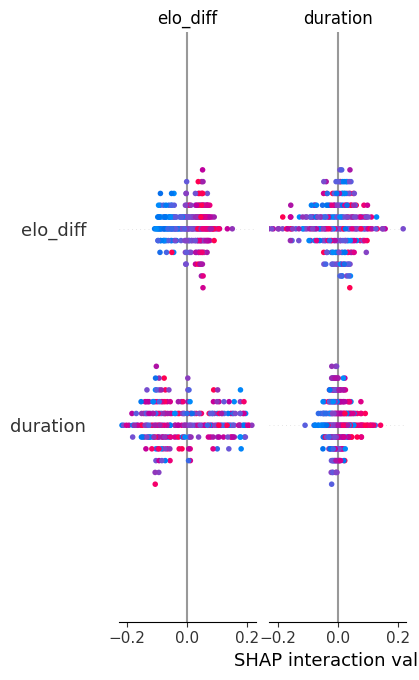

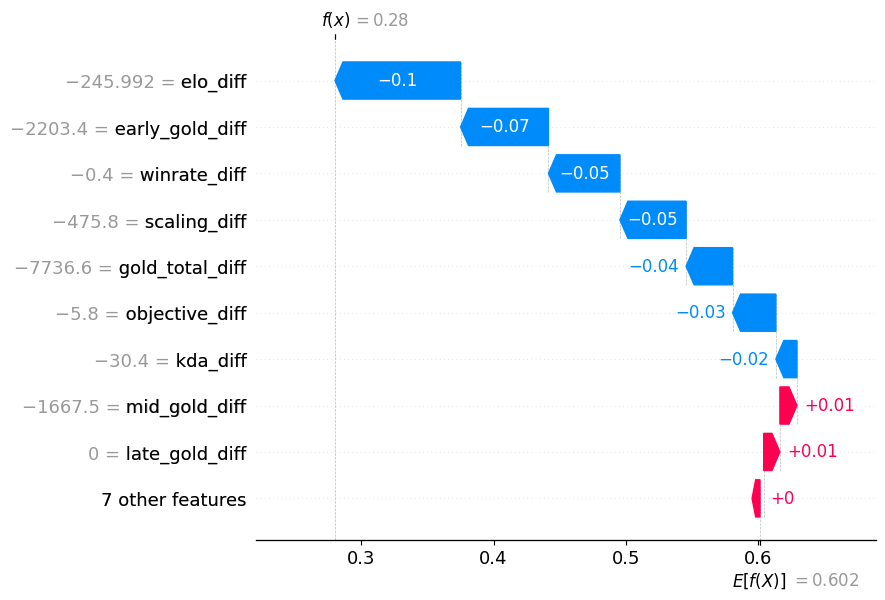

XGB
                    feature  importance
4           gold_total_diff    0.130247
3            objective_diff    0.095542
1                  elo_diff    0.082812
8              winrate_diff    0.081292
10             scaling_diff    0.077522
9             momentum_diff    0.068401
11       comeback_rate_diff    0.064708
15   late_gold_diff_missing    0.063227
5           early_gold_diff    0.061754
6             mid_gold_diff    0.060824
0                  duration    0.060258
2                  kda_diff    0.057825
7            late_gold_diff    0.055471
14    mid_gold_diff_missing    0.040116
13  early_gold_diff_missing    0.000000
12  gold_total_diff_missing    0.000000
XGB
not list
(257, 16)


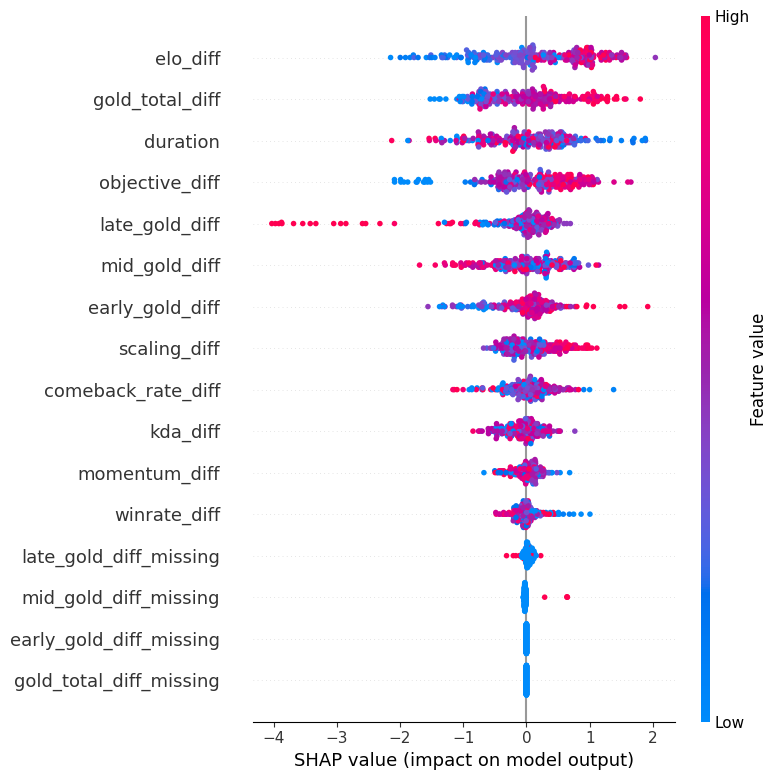

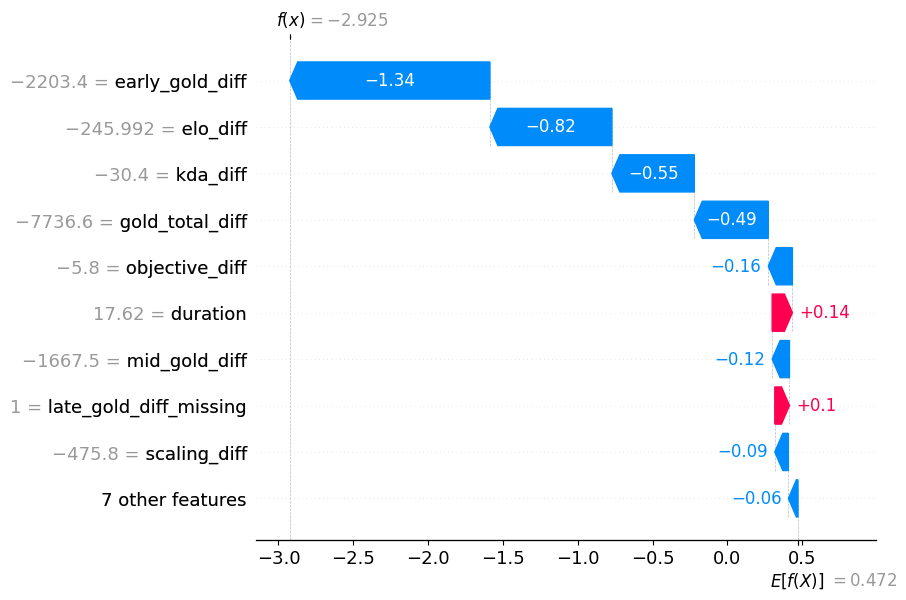

,model,Loss,Acc,ROC_AUC,F1,CM
0,LogisticRegression(),0.619071,0.587549,0.716539,0.459184,"[[106, 17], [89, 45]]"
1,"(DecisionTreeClassifier(max_features='sqrt', r...",0.676428,0.564202,0.657778,0.397849,"[[108, 15], [97, 37]]"
2,"XGBClassifier(base_score=None, booster=None, c...",0.911331,0.610895,0.662541,0.593496,"[[84, 39], [61, 73]]"


In [156]:
X = df_final[[
    "duration",
    "elo_diff",
    "kda_diff",
    "objective_diff",
    "gold_total_diff",
    "early_gold_diff",
    "mid_gold_diff",
    "late_gold_diff",
    "winrate_diff",
    "momentum_diff",
    "scaling_diff",
    "comeback_rate_diff",
    "gold_total_diff_missing",
    "early_gold_diff_missing",
    "mid_gold_diff_missing",
    "late_gold_diff_missing" 
]]

y = df_final["label"].astype(int)

# # Count Label Distribution
# print(y.value_counts(normalize=True))

result = []

model = {
    "Logistic": LogisticRegression(),
    "RF": RandomForestClassifier(),
    "XGB": XGBClassifier()
}

for name, model, in model.items():
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

    if name == "Logistic":
        scaler = StandardScaler()
        X_train = scaler.fit_transform(X_train)
        X_test = scaler.transform(X_test)

    model.fit(X_train, y_train)

    if name == "RF" or name == "XGB":
        # Feature Importance
        importance = model.feature_importances_

        feat_imp = pd.DataFrame({
            "feature": X.columns,
            "importance": importance
        }).sort_values(by="importance", ascending=False)
        print(name)
        print(feat_imp)
    
    if name == "Logistic":
        print(name)
        print(model.coef_)
        explainer = shap.LinearExplainer(model, X_train)
        shap_values = explainer(X_test)
        shap.summary_plot(shap_values, X_test)
        shap.plots.waterfall(shap_values[0])

    if name == "RF":
        print(name)
        explainer = shap.TreeExplainer(model)
        shap_values = explainer(X_test, check_additivity=False)
        print(len(shap_values) if isinstance(shap_values, list) else "not list")
        print(shap_values.shape)
            
        shap.summary_plot(shap_values, X_test)
        shap.plots.waterfall(shap_values[0, :, 1])
    
    if name == "XGB":
        print(name)
        explainer = shap.TreeExplainer(model)
        shap_values = explainer(X_test, check_additivity=False)
        print(len(shap_values) if isinstance(shap_values, list) else "not list")
        print(shap_values.shape)
            
        shap.summary_plot(shap_values, X_test)
        shap.plots.waterfall(shap_values[0])
    
    y_pred_probability = model.predict_proba(X_test)[:,1]
    y_pred = (y_pred_probability > 0.75).astype(int)

    # # Debug for model class predict ditribution
    # print(pd.Series(y_pred).value_counts(normalize=True))
    # print(pd.Series(y_pred_probability).describe())

    # # Debug for histogram class predict probability
    # plt.hist(y_pred_probability, bins=20)
    # plt.title("Probability Distribution")
    # plt.show()
    

    result.append({
        "model": model,
        "Loss": log_loss(y_test, y_pred_probability),
        "Acc": accuracy_score(y_test, y_pred),
        "ROC_AUC": roc_auc_score(y_test, y_pred_probability),
        "F1": f1_score(y_test, y_pred),
        "CM": confusion_matrix(y_test, y_pred)})

pd.DataFrame(result)

In [246]:
# Top 4 Importance Feature
X = df_final[[
    "elo_diff",
    "objective_diff",
    "winrate_diff",
    "scaling_diff"
]]

y = df_final["label"].astype(int)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(max_iter=1000))
])

pipeline.fit(X_train, y_train)

y_proba = pipeline.predict_proba(X_test)[:,1]
y_pred = (y_proba > 0.5).astype(int)

threshold = np.linspace(0.3, 0.7, 50)

best_f1 = 0
best_threshold = 0.5

for t in threshold:
    y_pred = (y_proba > t).astype(int)
    f1 = f1_score(y_test, y_pred)

    if f1 > best_f1:
        best_f1 = f1
        best_t = t

print(f"Best threshold: {best_f1}.")
print(f"Accuracy Score: {accuracy_score(y_test, y_pred)}.")
print(f"Loss Score: {log_loss(y_test, y_proba)}.")
print(f"ROC-AUC Score: {roc_auc_score(y_test, y_proba)}.")
print(f"Confusion matrix : {confusion_matrix(y_test, y_pred)}.")

Best threshold: 0.7492260061919505.
Accuracy Score: 0.6342412451361867.
Loss Score: 0.610784987406538.
ROC-AUC Score: 0.732829753670671.
Confusion matrix : [[101  22]
 [ 72  62]].


In [247]:
coef = pipeline.named_steps["model"].coef_[0]
for f, c in zip(X.columns, coef):
    print(f, c)

elo_diff 0.2937459635835036
objective_diff 0.4358072894387526
winrate_diff 0.09846620101641693
scaling_diff 0.1688023971780932


In [257]:
sample = [[50, 10, 0.9, 300]]

proba = pipeline.predict_proba(sample)[0][1]
print(f"probalilitas home menang: {proba}")

probalilitas home menang: 0.8223456125864463


c:\Users\ACER\miniconda3\envs\mworld\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [264]:
df_eval = X_test.copy()
df_eval["y_true"] = y_test
df_eval["y_pred"] = y_pred
df_eval["proba"] = y_proba
fn = df_eval[(df_eval["y_true"] == 0) & (df_eval["y_pred"] == 0)]
fn.sort_values(by="proba", ascending=True)

,elo_diff,objective_diff,winrate_diff,scaling_diff,y_true,y_pred,proba
1134,-619.839131,-12.0,-0.8,-735.4,0,0,0.126652
1212,-268.379167,-13.6,-0.8,-1279.8,0,0,0.156600
1202,-221.698057,-15.4,-0.6,-1244.8,0,0,0.156738
1128,-860.592929,-5.6,-0.4,-445.8,0,0,0.164105
1178,-184.412379,-13.8,-1.0,-1281.0,0,0,0.165164
...,...,...,...,...,...,...,...
1195,83.442215,2.2,0.2,143.6,0,0,0.683372
1072,-0.087116,3.5,0.0,461.0,0,0,0.687734
1182,64.496715,1.8,0.2,460.0,0,0,0.692967
1218,149.036783,2.2,0.2,-22.6,0,0,0.693497


## **Insights**

**Error Analysis**

- Model struggle dalam beberapa kondisi seperti selisih elo yang kecil dan comeback yang terjadi dalam game sehingga match terlihat ketat dengan probabilitas antara 0.4 hingga 0.65
- Model terlalu percaya dengan elo dan objective sehingga model salah memprediksi ketika menang dalam sisi scaling namun kalah dalam sisi objective dengan kata lain comeback

**Segment Analysis**

- Model lebih akurat pada match dengan gap power strenght dan eco efficiency yang besar dibandingkan dengan match yang gap yang ketat
- Feature elo dan objective terlalu dominan sehingga menutupi kontribusi feature winrate saat model memprediksi sebuah match